2026/01/21 By Li.Jiahao
Previously, we explored two fundamental classes of quantum algorithms. We saw how query-based algorithms leverage oracles to identify items within black box, and how QFT offers a unique mechanism for extracting information in unconventional ways. 
In this post, I will introduce the Grover algorithm -- a powerful quantum search algorithm designed to solve black-box searching problem with quadratic speedup.

# Grover algorithm
## 1.1 Problem statement
Image you are trying crack a safe with a n-bit password,denote as x. We can represent this search as a function $f: \{0,1\}^n \rightarrow \{0,1\}$, where:

f(w) = 1,if w=x.

f(w)=0,if w!=x.

In a classical scenario,since we don't know the structure of the password, we must try every conbination one by one.On average, it would take $2^{n-1}$ attempts to find the correct one. In the following sections, we will explore how Grover’s algorithm achieves a quadratic speedup, finding the solution in only $O(\sqrt{2^n})$ steps.


## 1.2 description of the algorithm
### 1.2.1 Phase query gates
Let's begin with a new gate called phase query gate which only changes the phase of a state according to the input state, defined as :
$$Z_f \vert x\rangle = (-1)^{f(x)} \vert x\rangle$$
The circuit diagram is shown as below:

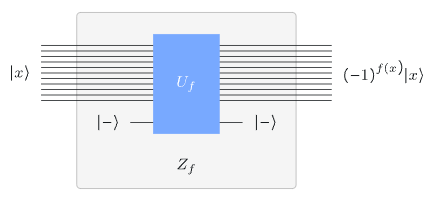

This is slightly different from the phase kick-back circuit. We use an auxiliary qubit in state $|-\rangle$ but not $|0\rangle$ because  we want encode the information into phase(phase oracle), rather than the state(bit oracle). This distinction is clarified by comparing the two operations below:
$$
U_f |x\rangle |0\rangle = |x\rangle |0 \oplus f(x)\rangle = |x\rangle |f(x)\rangle
$$
$$
U_f |x\rangle |-\rangle = |x\rangle \left( \frac{|0 \oplus f(x)\rangle - |1 \oplus f(x)\rangle}{\sqrt{2}} \right)
$$
Consider a special case where the function is an OR operation
$$\mathrm{OR}(x) =
\begin{cases}
  0 & x = 0^n\\[0.5mm]
  1 & x \neq 0^n
\end{cases}$$

Then we can get a special phase query gate(Reflection about the zero state):

$$
Z_{\mathrm{OR}} \vert x\rangle
= \begin{cases}
  \vert x\rangle & x = 0^n \\[0.5mm]
- \vert x\rangle & x \neq 0^n.
\end{cases}
$$

### 1.2.2 Algorithm details
We briefly describe the program as below:

~ 1.Prepare n qubits and initialize them into state $|+\rangle$. Denote this as register Q.

~ 2.Apply the composite operator $G = H^{\otimes n} Z_{\mathrm{OR}} H^{\otimes n}$ Z_f to Q.

~ 3.Measure the Q get result.

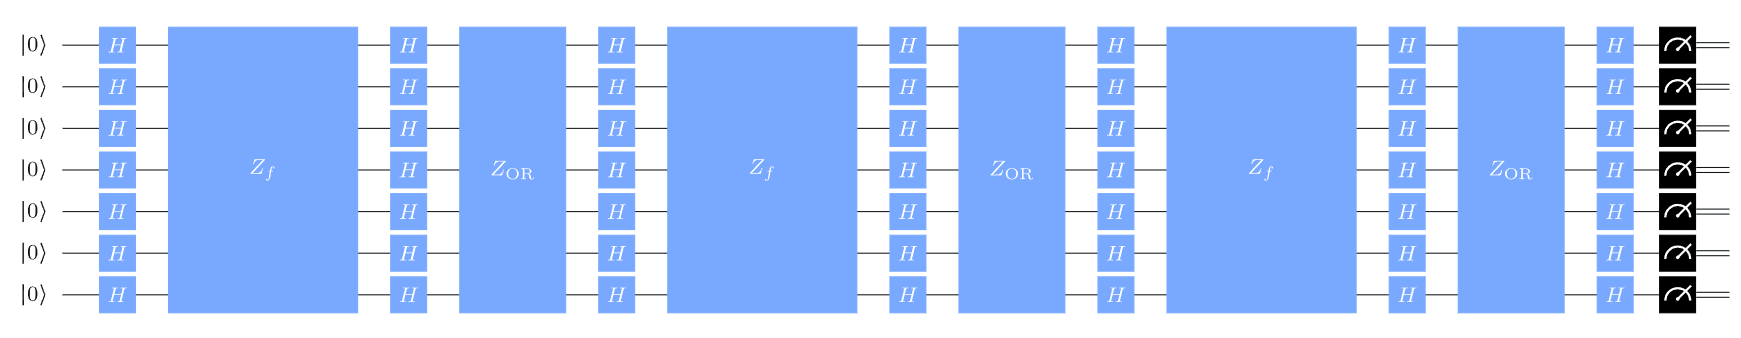

Explanation:
$Z_f$ represent the keyhole of the safe. But you might be puzzled that if we already know the keyhole why we need to design an algorithm to find the key. In reality, the 'keyhole' is always an abstract problem. For instance, In a  hash-collision or pre-image attack, we know the hash funtion and the target hash value. While we can construct a circuit $f$ that implements this hash logic, we cannot "see" which input $x$ leads to the target value without searching. Grover's algorithm allows us to find that input by querying the "keyhole" circuit.

### 1.2.3 Mathematical analysis

Let's begin by partitioning the computational basis into two orthogonal sets: one containing the solutions and the other containing non-solutions. These are defined as:
$$\begin{aligned}
  A_0 &= \bigl\{ x\in\Sigma^n : f(x) = 0\bigr\} \\
  A_1 &= \bigl\{ x\in\Sigma^n : f(x) = 1\bigr\}
\end{aligned}$$

We can represent the initial equal superposition state $|u\rangle$ as a linear combination of these two normalized states:
$$\vert u\rangle
= \sqrt{\frac{\vert A_0 \vert}{N}} \vert A_0\rangle
+ \sqrt{\frac{\vert A_1 \vert}{N}} \vert A_1\rangle.
$$
When we apply the Phase Oracle $Z_f$ to these components:
\begin{aligned}
Z_f \vert A_0\rangle & = \vert A_0\rangle \\[1mm]
Z_f \vert A_1\rangle & = -\vert A_1\rangle
\end{aligned}
So, we can rewrite the expression of Or-gate:
$$Z_{\mathrm{OR}} = 2 \vert 0^n \rangle \langle 0^n \vert - \mathbb{I}.$$
Next expand the Or-gate into $H^{\otimes n} Z_{\mathrm{OR}} H^{\otimes n}$:
$$H^{\otimes n} Z_{\mathrm{OR}} H^{\otimes n} = 2 H^{\otimes n} \vert 0^n \rangle \langle 0^n \vert H^{\otimes n} - \mathbb{I} = 2 \vert u \rangle \langle u \vert - \mathbb{I},$$
And then look at applying oparetor G to $\vert A_0\rangle$ and $\vert A_1\rangle$ :
$$
\begin{aligned}
  G \vert A_0 \rangle
  & = \bigl( 2 \vert u\rangle \langle u \vert - \mathbb{I}\bigr) Z_f \vert A_0\rangle \\
  & = \bigl( 2 \vert u\rangle \langle u \vert - \mathbb{I}\bigr) \vert A_0\rangle \\
  & = 2 \sqrt{\frac{\vert A_0\vert}{N}} \vert u\rangle -\vert A_0 \rangle\\
  & = 2 \sqrt{\frac{\vert A_0\vert}{N}} \biggl(
  \sqrt{\frac{\vert A_0\vert}{N}} \vert A_0\rangle + \sqrt{\frac{\vert A_1\vert}{N}} \vert A_1\rangle\biggr)
  -\vert A_0 \rangle \\
  & = \biggl( \frac{2\vert A_0\vert}{N} - 1\biggr) \vert A_0 \rangle
  + \frac{2 \sqrt{\vert A_0\vert \cdot \vert A_1\vert}}{N} \vert A_1 \rangle \\
  & = \frac{\vert A_0\vert - \vert A_1\vert}{N} \vert A_0 \rangle
  + \frac{2 \sqrt{\vert A_0\vert \cdot \vert A_1\vert}}{N} \vert A_1 \rangle
\end{aligned}
\begin{aligned}
  G \vert A_1 \rangle
  & = \bigl( 2 \vert u\rangle \langle u \vert - \mathbb{I} \bigr) Z_f \vert A_1\rangle \\
  & = - \bigl( 2 \vert u\rangle \langle u \vert - \mathbb{I} \bigr) \vert A_1\rangle \\
  & = - 2 \sqrt{\frac{\vert A_1\vert}{N}} \vert u\rangle + \vert A_1 \rangle \\
  & = - 2 \sqrt{\frac{\vert A_1\vert}{N}} \biggl(\sqrt{\frac{\vert A_0\vert}{N}} \vert A_0\rangle
      + \sqrt{\frac{\vert A_1\vert}{N}} \vert A_1\rangle\biggr) + \vert A_1 \rangle \\
  & = - \frac{2 \sqrt{\vert A_1\vert \cdot \vert A_0\vert}}{N} \vert A_0 \rangle
      + \biggl( 1 - \frac{2\vert A_1\vert}{N} \biggr) \vert A_1 \rangle \\
  & = - \frac{2 \sqrt{\vert A_1\vert \cdot \vert A_0\vert}}{N} \vert A_0 \rangle
      + \frac{\vert A_0\vert - \vert A_1\vert}{N} \vert A_1 \rangle
\end{aligned}
$$
We use a matrix to denote the function of operator G:
$$M = \begin{pmatrix}
  \frac{\vert A_0\vert - \vert A_1\vert}{N} & -\frac{2 \sqrt{\vert A_1\vert \cdot \vert A_0\vert}}{N} \\[2mm]
  \frac{2 \sqrt{\vert A_0\vert \cdot \vert A_1\vert}}{N} & \frac{\vert A_0\vert - \vert A_1\vert}{N}
\end{pmatrix},$$
Here exist a not obvious mathematic transform-- we can get the root of M:
$$\sqrt{M} = \begin{pmatrix}
  \sqrt{\frac{\vert A_0\vert}{N}} & - \sqrt{\frac{\vert A_1\vert}{N}} \\[2mm]
  \sqrt{\frac{\vert A_1\vert}{N}} & \sqrt{\frac{\vert A_0\vert}{N}}
\end{pmatrix}
=
\begin{pmatrix}
  \cos(\theta) & -\sin(\theta) \\[2mm]
  \sin(\theta) & \cos(\theta)
\end{pmatrix}$$ 
So, we have:
$$M = \begin{pmatrix}
  \cos(\theta) & -\sin(\theta) \\[2mm]
  \sin(\theta) & \cos(\theta)
\end{pmatrix}^2
= \begin{pmatrix}
  \cos(2\theta) & -\sin(2\theta) \\[2mm]
  \sin(2\theta) & \cos(2\theta)
\end{pmatrix}.$$
And state $|u\rangle$ can be change the form:
$$\vert u\rangle
= \sqrt{\frac{\vert A_0\vert}{N}} \vert A_0\rangle
+ \sqrt{\frac{\vert A_1\vert}{N}} \vert A_1\rangle
= \cos(\theta) \vert A_0\rangle + \sin(\theta) \vert A_1\rangle,$$
The effect of operator G is equal to apply $2\theta$ rotation to state $|u\rangle$:
$$
\begin{aligned}
G \vert u \rangle &= \cos(3\theta) \vert A_0\rangle + \sin(3\theta) \vert A_1\rangle\\[1mm]
G^2 \vert u \rangle &= \cos(5\theta) \vert A_0\rangle + \sin(5\theta) \vert A_1\rangle\\[1mm]
G^3 \vert u \rangle &= \cos(7\theta) \vert A_0\rangle + \sin(7\theta) \vert A_1\rangle
\end{aligned}
$$
As we have mentioned, since set A1 contains the solution we need, we should apply multiply times G operator to ensure coefficient of $\vert A_1\rangle$ is near to 1, besides the other near to 0. At this point, a measurement will yield a correct solution with high probability.

### 1.2.4 Choosing the number of iterations
Based on derivation above, parameter $\theta$ is related to the ratio between $|A_1|$ and $N$. So let's talk about how we choose the number of iterations.

If we know that noly a single solution exists, we can derive $\theta$:
$$\theta = \sin^{-1}\biggl( \sqrt{\frac{1}{N}} \biggr) \approx \sqrt{\frac{1}{N}} \text{(only when N is large enough)}$$
So we get the reasonable  number of iterations t:
$$t = \Bigl\lfloor \frac{\pi}{4\theta} \Bigr\rfloor  = \Bigl\lfloor \frac{\pi}{4}\sqrt{N} \Bigr\rfloor.$$
We denote the probability of obtain the correct solution as p(N,1):
$$p(N,1) = \sin^2 \bigl( (2t + 1) \theta \bigr).$$
And here is a table theoretically:
$$\begin{array}{ll}
N & p(N,1)\\ \hline
2	& 0.5000000000\\
4	& 1.0000000000\\
8	& 0.9453125000\\
16	& 0.9613189697\\
32	& 0.9991823155\\
64	& 0.9965856808\\
128	& 0.9956198657\\
256	& 0.9999470421\\
512	& 0.9994480262\\
1024 &	 0.9994612447\\
2048 &	 0.9999968478\\
4096 &	 0.9999453461\\
8192 &	 0.9999157752\\
16384 &	 0.9999997811\\
32768 &	 0.9999868295\\
65536 &	 0.9999882596
\end{array}$$
The conclusion is that we can get quite high probability when there exist single solution.
But concerning the scenario with multiple solutions, it will be more complex.Suppose that there are 's' correct solutions.We use the recommonded choice of t:
$ t = \Bigl\lfloor \frac{\pi}{4\theta}\Bigr\rfloor $ 
So, $$\theta = \sin^{-1}\left(\sqrt{\frac{s}{N}}\right) \geq \sqrt{\frac{s}{N}}.$$
This implies:
$$t \leq \frac{\pi}{4\theta} \leq \frac{\pi}{4}\sqrt{\frac{N}{s}}.$$
Sometimes, we need to adjust the rotation times to make it reasonable.
And how about the situation when we don't know the number of solutions. We have two ways. One is to try randomly and hope we can hit the ball as fast as it could. And the second is try from 1 to n.
